# Import required libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# Load the dataset

In [2]:
healthLifestyle_data = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")
healthLifestyle_data.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [3]:
healthLifestyle_data[['Systolic_Pressure', 'Diastolic_Pressure']] = (
    healthLifestyle_data['Blood Pressure']
    .str.split('/', expand=True)
).astype("int")
healthLifestyle_data.drop("Blood Pressure", axis=1, inplace=True)

In [4]:
healthLifestyle_data.columns

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder', 'Systolic_Pressure', 'Diastolic_Pressure'],
      dtype='str')

In [5]:
healthLifestyle_data.dtypes

Person ID                    int64
Gender                         str
Age                          int64
Occupation                     str
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                   str
Blood Pressure                 str
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder                 str
Systolic_Pressure            int64
Diastolic_Pressure           int64
dtype: object

In [6]:
healthLifestyle_data.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Systolic_Pressure,Diastolic_Pressure
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN,125,80
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90


In [7]:
healthLifestyle_data.shape

(374, 15)

In [8]:
healthLifestyle_data[healthLifestyle_data["Sleep Disorder"].isna()]

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Systolic_Pressure,Diastolic_Pressure
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN,125,80
7,8,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN,120,80
8,9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN,120,80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
341,342,Female,56,Doctor,8.2,9,90,3,Normal Weight,118/75,65,10000,NaN,118,75
342,343,Female,56,Doctor,8.2,9,90,3,Normal Weight,118/75,65,10000,NaN,118,75
343,344,Female,57,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,NaN,140,95
358,359,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,NaN,140,95


In [9]:
healthLifestyle_data["Sleep Disorder"] = healthLifestyle_data["Sleep Disorder"].fillna("Healthy")
healthLifestyle_data.isna().sum()

Person ID                  0
Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Blood Pressure             0
Heart Rate                 0
Daily Steps                0
Sleep Disorder             0
Systolic_Pressure          0
Diastolic_Pressure         0
dtype: int64

Found that the BMI Category has "Normal" and "Normal Weight" which needs to be corrected.

In [10]:
healthLifestyle_data["BMI Category"] = healthLifestyle_data["BMI Category"].replace("Normal Weight","Normal")

# Data Visualization

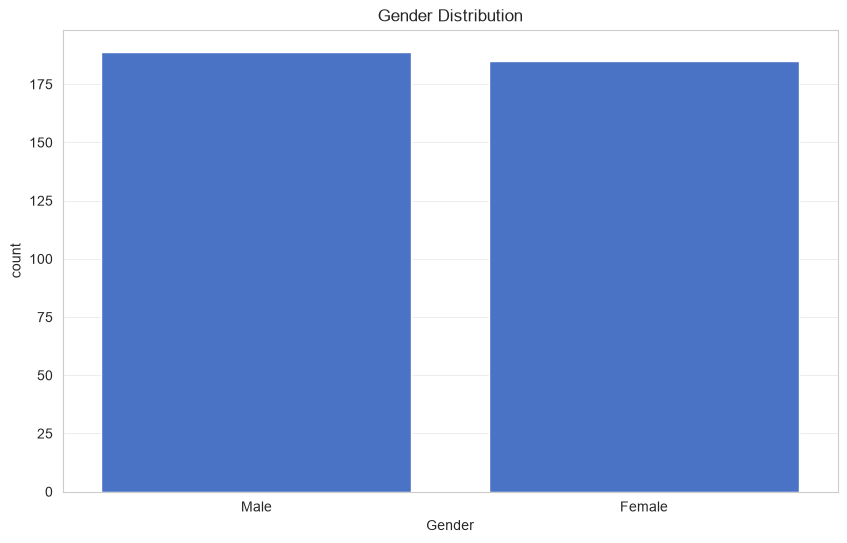

In [11]:
sns.countplot(data=healthLifestyle_data, x='Gender')
plt.title('Gender Distribution')
plt.show()

<Axes: xlabel='Age', ylabel='Count'>

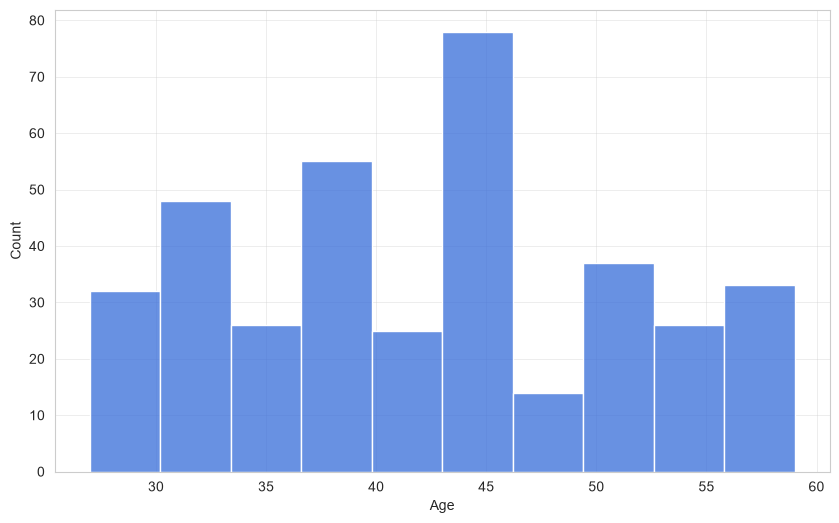

In [12]:
sns.histplot(data=healthLifestyle_data,x=healthLifestyle_data["Age"])


**Inference:**
- The dataset has almost equal distribution in Gender and approximate proportion age group has been indentified for the study.
- So the dataset can be considered to be balanced

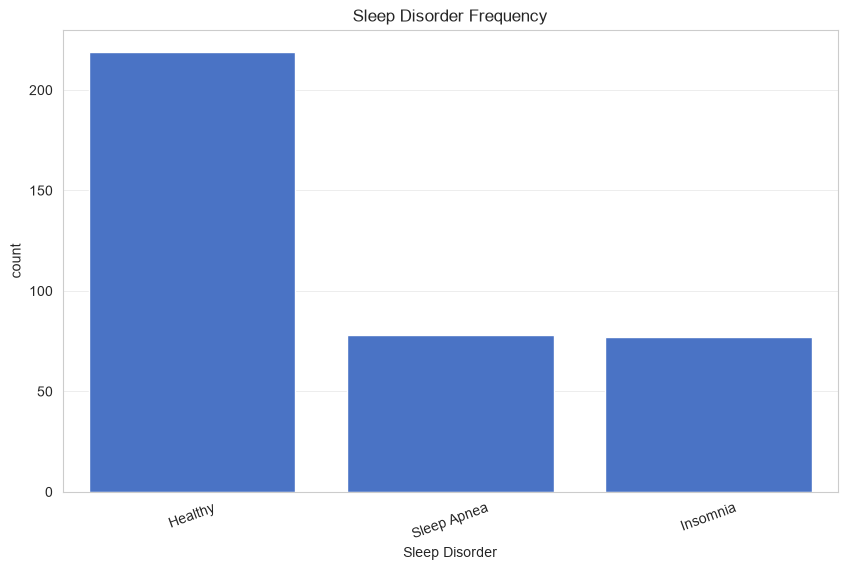

In [13]:
sns.countplot(
    data=healthLifestyle_data,
    x='Sleep Disorder',
    order=healthLifestyle_data['Sleep Disorder'].value_counts().index
)

plt.title('Sleep Disorder Frequency')
plt.xticks(rotation=20)
plt.show()

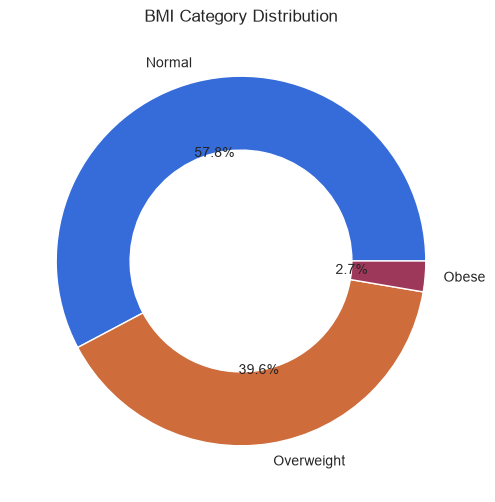

In [14]:
bmi_counts = healthLifestyle_data['BMI Category'].value_counts()

plt.pie(
    bmi_counts,
    labels=bmi_counts.index,
    autopct='%1.1f%%',
    wedgeprops={'width':0.4}
)

plt.title('BMI Category Distribution')
plt.show()

Almost half of the sample are normal and out of the remaining most of them are overweight

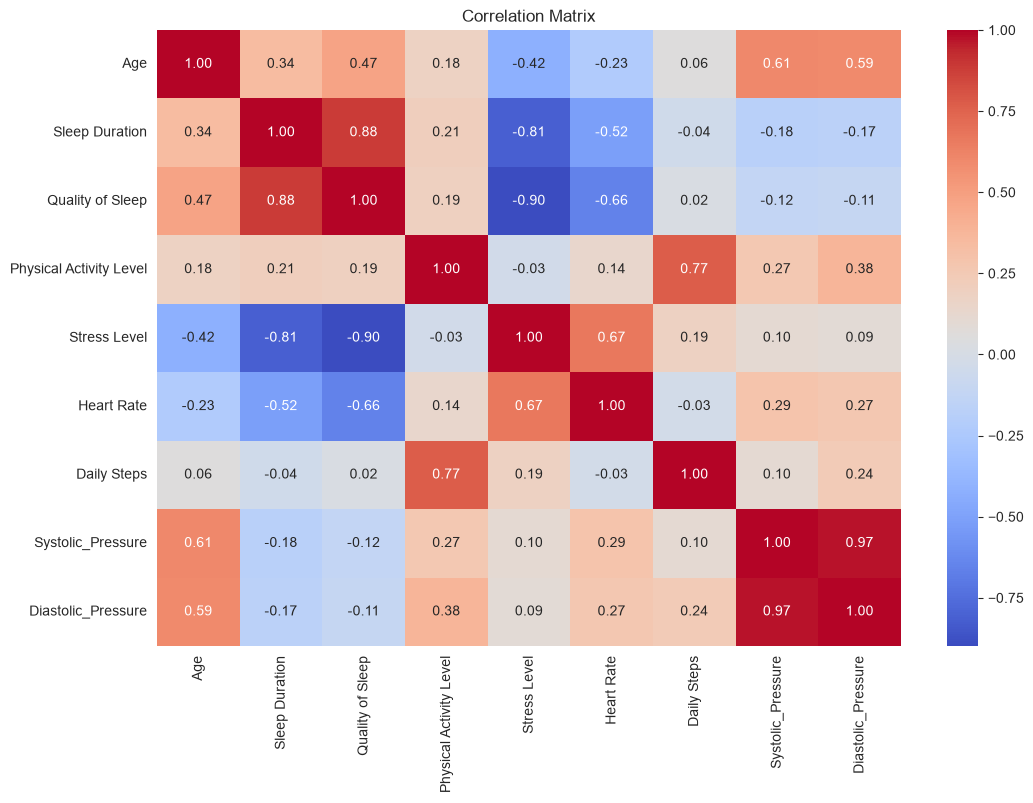

In [15]:
numeric_cols = [
    'Age',
    'Sleep Duration',
    'Quality of Sleep',
    'Physical Activity Level',
    'Stress Level',
    'Heart Rate',
    'Daily Steps',
    'Systolic_Pressure',
    'Diastolic_Pressure'
]

corr = healthLifestyle_data[numeric_cols].corr()

plt.figure(figsize=(12,8))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation Matrix')
plt.show()

**Inferences:**
- The Age has impact on the blood pressure while no highlighting impact on the heart rate and stress levels.
- While the Stress level has a major relation with the heart rate.
- The Duration of Sleep and the Quality of Sleep are directly proportional to each other.
- The Stress has negative impact on the sleep duration and which leads to impact on the heart rate.

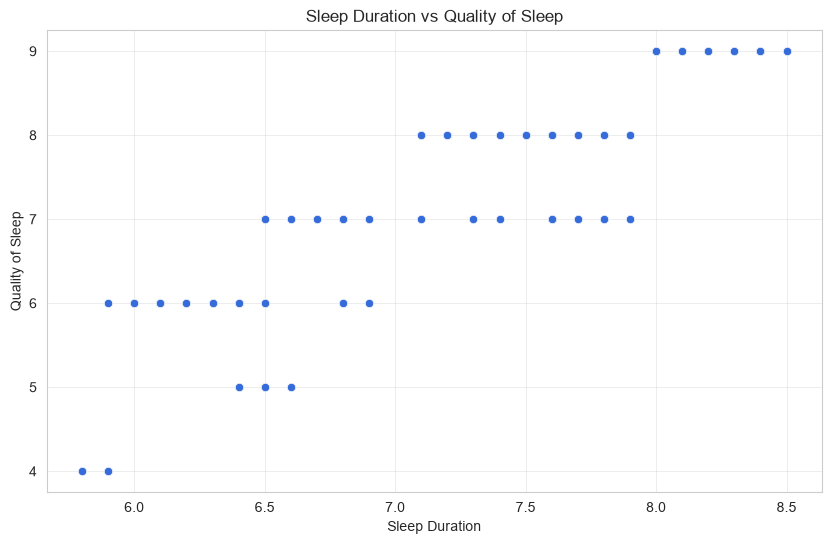

In [16]:
sns.scatterplot(
    data=healthLifestyle_data,
    x='Sleep Duration',
    y='Quality of Sleep'
)

plt.title('Sleep Duration vs Quality of Sleep')
plt.show()

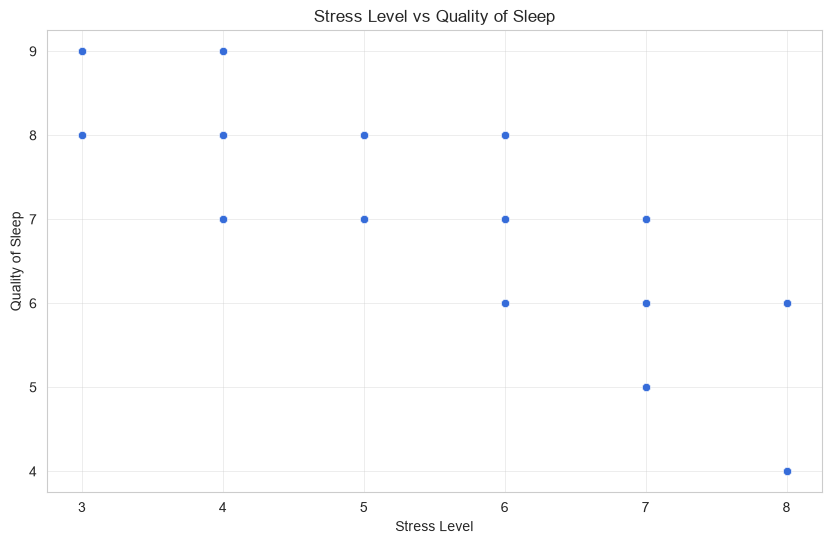

In [17]:
sns.scatterplot(
    data=healthLifestyle_data,
    x='Stress Level',
    y='Quality of Sleep'
)

plt.title('Stress Level vs Quality of Sleep')
plt.show()

**More the sleep duration, more the Quality of sleep**


**Also higher the stress, less quality of sleep**

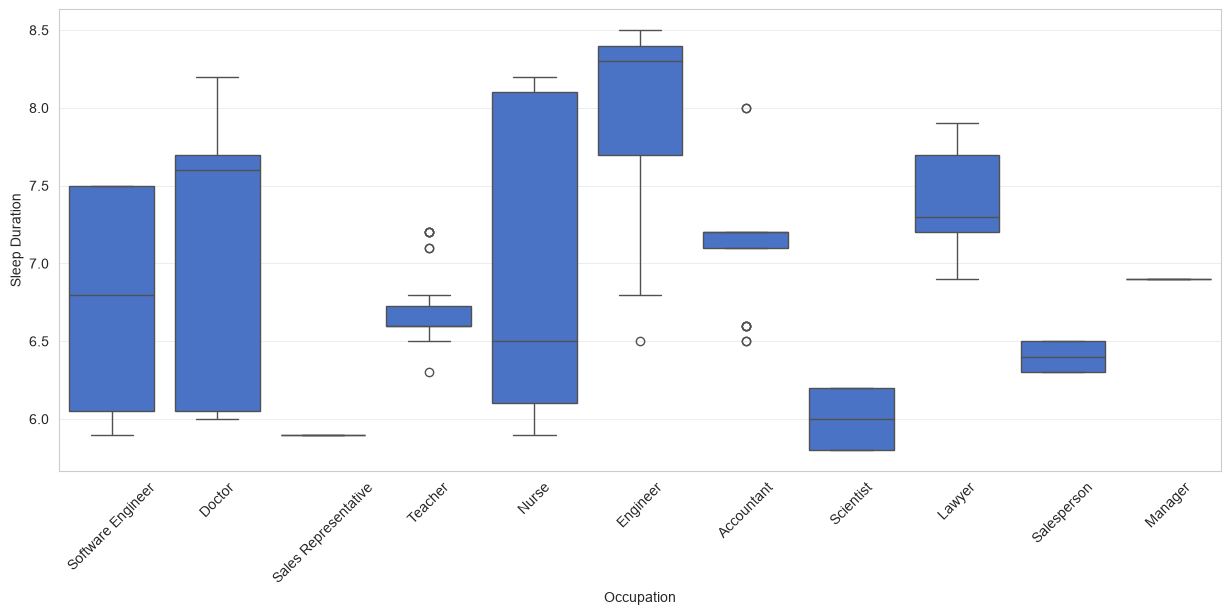

In [18]:
plt.figure(figsize=(15,6))

sns.boxplot(
    data=healthLifestyle_data,
    x='Occupation',
    y='Sleep Duration'
)

plt.xticks(rotation=45)
plt.show()

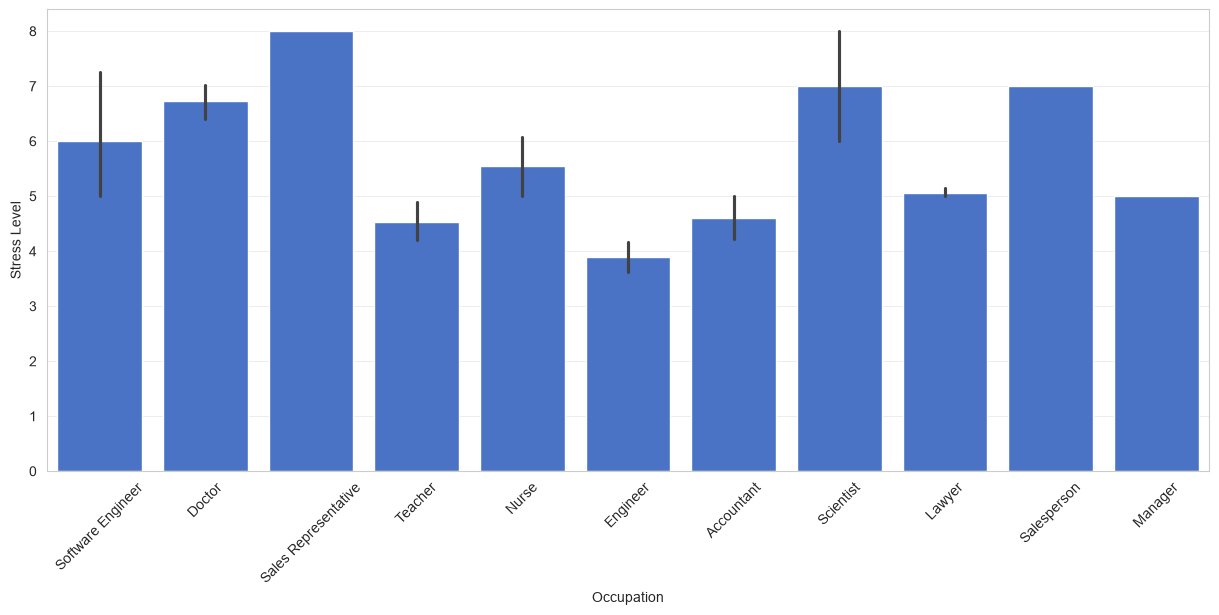

In [19]:
plt.figure(figsize=(15,6))

sns.barplot(
    data=healthLifestyle_data,
    x='Occupation',
    y='Stress Level'
)

plt.xticks(rotation=45)
plt.show()

From the above plots,
- The scientists, sales people has the less sleep duration due to the higher stress in the work place.
- Though there is high stress in the work place, the doctors are being health conscious.
- Also, the fun fact is that, the engineers are sleeping longer time despite low stress in the job.

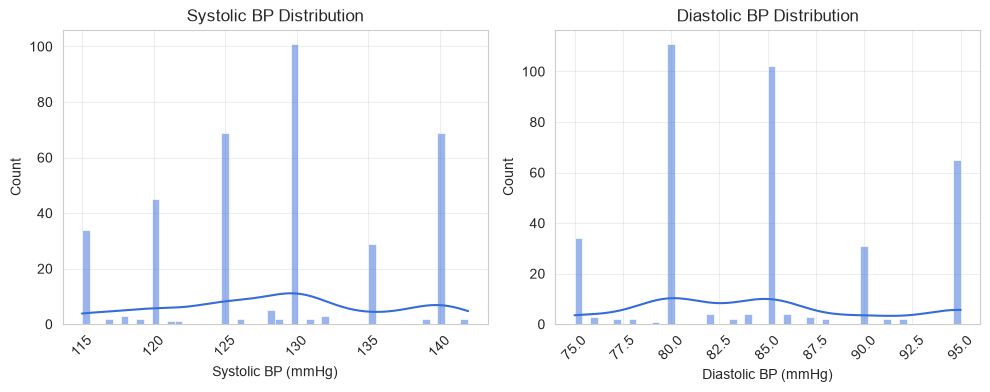

In [20]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
sns.histplot(
    healthLifestyle_data['Systolic_Pressure'],
    bins=50,
    kde=True,
    ax=axes[0]
)
axes[0].set_title('Systolic BP Distribution')
axes[0].set_xlabel('Systolic BP (mmHg)')
axes[0].tick_params(axis='x', rotation=45)

sns.histplot(
    healthLifestyle_data['Diastolic_Pressure'],
    bins=50,
    kde=True,
    ax=axes[1]
)
axes[1].set_title('Diastolic BP Distribution')
axes[1].set_xlabel('Diastolic BP (mmHg)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

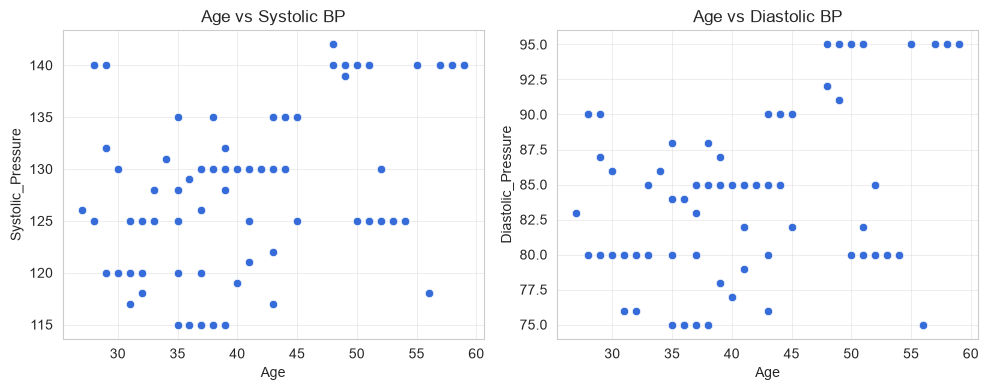

In [21]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
sns.scatterplot(
    data=healthLifestyle_data,
    x="Age",
    y="Systolic_Pressure",
    ax=axes[0]
)
axes[0].set_title('Age vs Systolic BP')

sns.scatterplot(
    data=healthLifestyle_data,
    x="Age",
    y="Diastolic_Pressure",
    ax=axes[1])
axes[1].set_title('Age vs Diastolic BP')

plt.tight_layout()
plt.show()

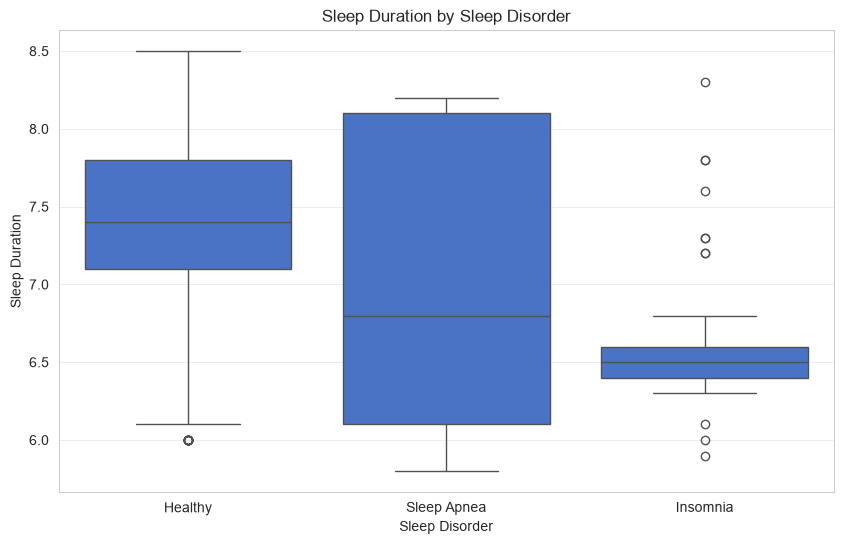

In [22]:
sns.boxplot(
    data=healthLifestyle_data,
    x='Sleep Disorder',
    y='Sleep Duration'
)

plt.title('Sleep Duration by Sleep Disorder')
plt.show()

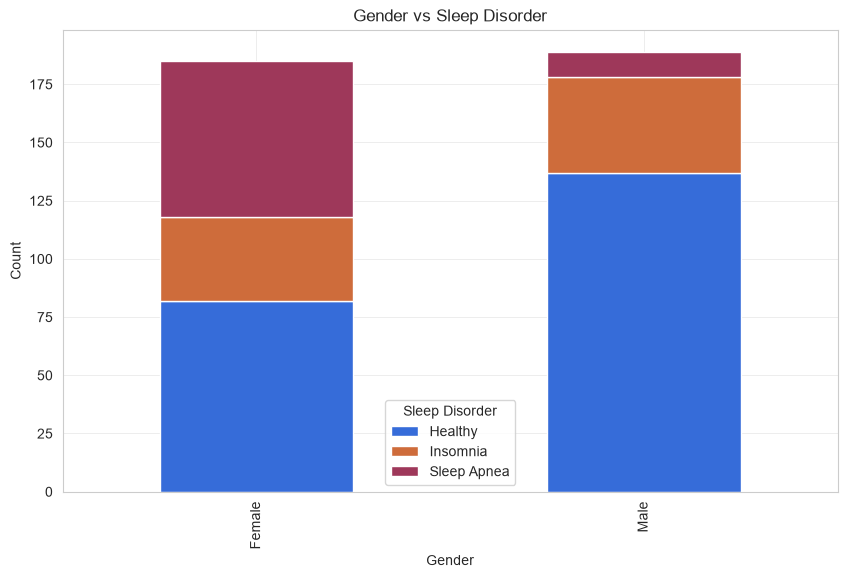

In [23]:
gender_sleep = pd.crosstab(
    healthLifestyle_data['Gender'],
    healthLifestyle_data['Sleep Disorder']
)

gender_sleep.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Gender vs Sleep Disorder')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Sleep Disorder')
plt.show()

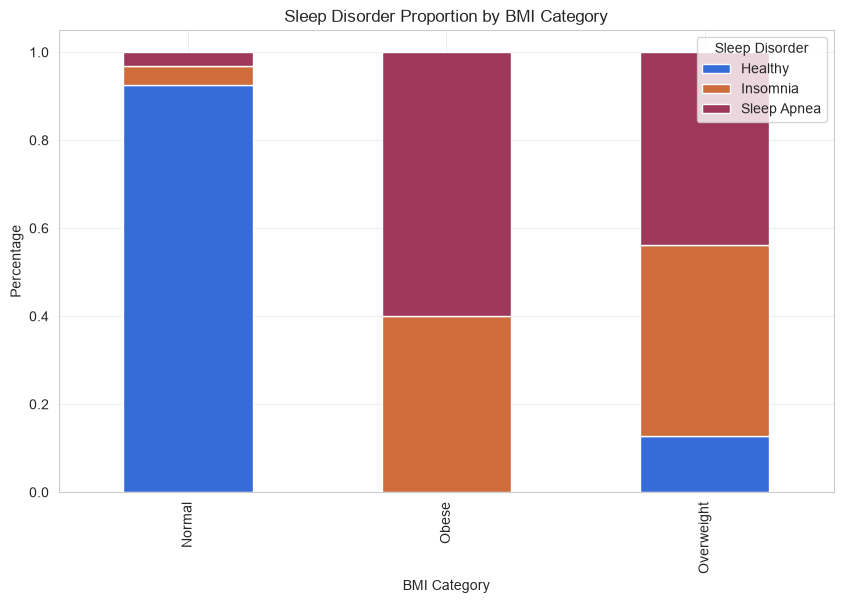

In [24]:
cross_tab = pd.crosstab(
    healthLifestyle_data['BMI Category'],
    healthLifestyle_data['Sleep Disorder'],
    normalize='index'
)

cross_tab.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Sleep Disorder Proportion by BMI Category')
plt.ylabel('Percentage')
plt.legend(title='Sleep Disorder')
plt.show()

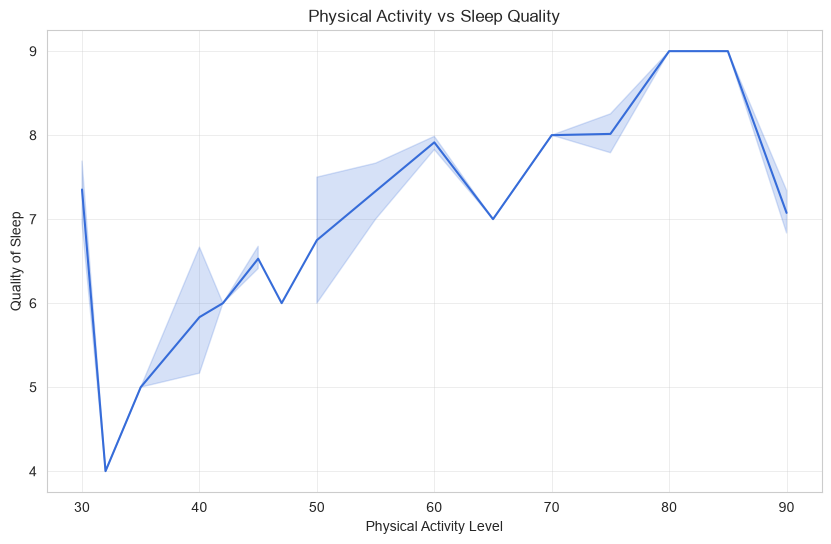

In [25]:
sns.lineplot(
    data=healthLifestyle_data.sort_values('Physical Activity Level'),
    x='Physical Activity Level',
    y='Quality of Sleep'
)

plt.title('Physical Activity vs Sleep Quality')
plt.show()